In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from google.colab import files
from scipy.optimize import minimize

In [23]:
#PARTIE 1

In [24]:
# QUESTION 1.5

def fct_euler_exp(u0, lbda, h, T):
    U = [u0]
    i = 0
    Temps = [0]
    while i * h <= T:
        U.append(U[-1] + h * lbda * U[-1])
        Temps.append((i + 1) * h)
        i = i + 1
    return (U, Temps)

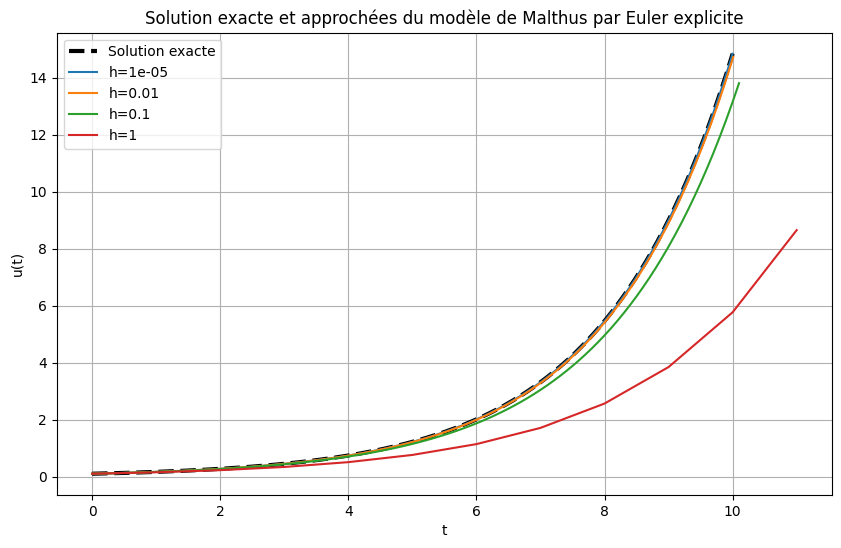

In [25]:
# QUESTION 1.6

def slt_exacte_Malthus(u0, lbda, t):
    return u0 * np.exp(lbda * t)

t_solution = np.linspace(0, 10, 1000)
u_solution = slt_exacte_Malthus(0.1, 1/2, t_solution)
plt.figure(figsize=(10, 6))
plt.plot(t_solution, u_solution, label="Solution exacte", color='black', linestyle="--",linewidth=3)

for pas in [10**-5, 0.01, 0.1, 1]:
    u, v = fct_euler_exp(0.1, 1/2, pas, 10)
    plt.plot(v, u, label=f"h={pas}")

plt.title("Solution exacte et approchées du modèle de Malthus par Euler explicite")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.legend()
plt.grid()
plt.show()

In [26]:
# QUESTION 1.13

def fct_euler_imp(u0, lbda, h, T):
    U = [u0]
    i = 0
    Temps = [0]
    while i * h <= T:
        U.append(U[-1]*(1/(1-lbda*h)))
        Temps.append((i + 1) * h)
        i = i + 1
    return (U, Temps)

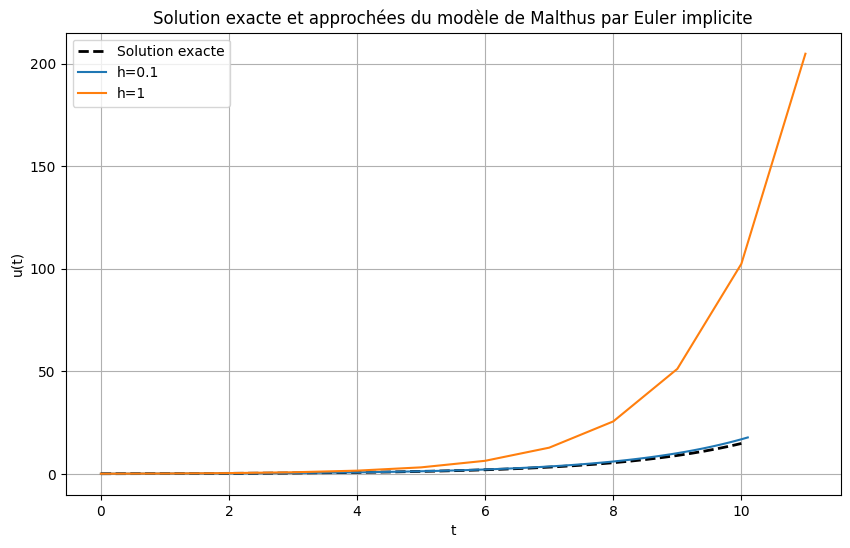

In [27]:
# QUESTION 1.14

t_solution = np.linspace(0, 10, 1000)
u_solution = slt_exacte_Malthus(0.1, 1/2, t_solution)
plt.figure(figsize=(10, 6))
plt.plot(t_solution, u_solution, label="Solution exacte", color='black', linestyle="--",linewidth=2)

for pas in [0.1, 1]:
    u, v = fct_euler_imp(0.1, 1/2, pas, 10)
    plt.plot(v, u, label=f"h={pas}")

plt.title("Solution exacte et approchées du modèle de Malthus par Euler implicite")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.legend()
plt.grid()
plt.show()

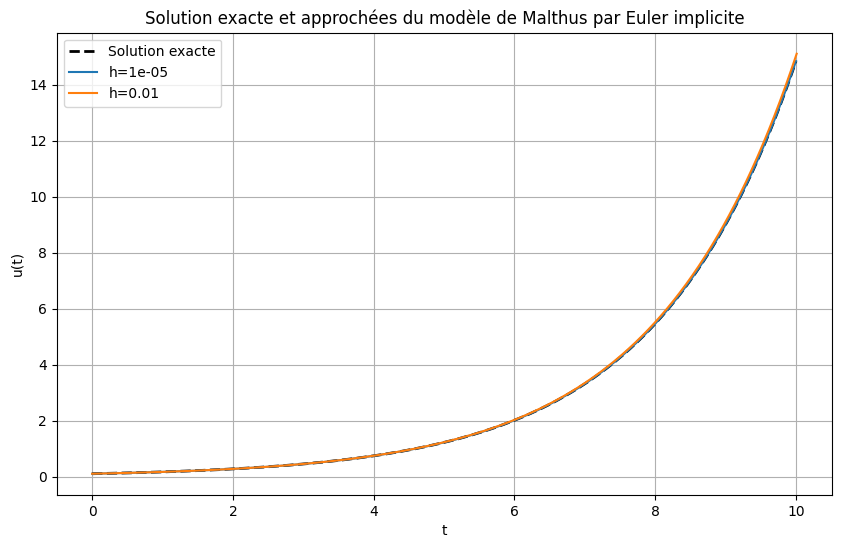

In [28]:
t_solution = np.linspace(0, 10, 1000)
u_solution = slt_exacte_Malthus(0.1, 1/2, t_solution)
plt.figure(figsize=(10, 6))
plt.plot(t_solution, u_solution, label="Solution exacte", color='black', linestyle="--",linewidth=2)

for pas in [10**-5, 0.01]:
    u, v = fct_euler_imp(0.1, 1/2, pas, 10)
    plt.plot(v, u, label=f"h={pas}")

plt.title("Solution exacte et approchées du modèle de Malthus par Euler implicite")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.legend()
plt.grid()
plt.show()

In [29]:
#PARTIE 2
epsilon=10e-6;

In [30]:
#QUESTION 2.2

def f(x,r,K):
    return r*x*(1-x/K)

def fct_point_milieu_log(r,K,u0,h,T):
    U = [u0]
    i = 0
    Temps = [0]
    while i * h <= T:
        U.append(U[-1] + h * f(U[-1]+h/2*f(U[-1],r,K),r,K))
        Temps.append((i + 1) * h)
        i = i + 1
    return (U, Temps)

In [31]:
#QUESTION 2.4

def point_fixe(f,r,K,u0,h,epsilon,max_iter):
    zprime=u0
    z=u0+h/2*(f(u0,r,K)+f(zprime,r,K))
    i=0
    while abs(z-zprime)>epsilon and i<max_iter:
        z=u0+h/2*(f(u0,r,K)+f(zprime,r,K))
        i=i+1
    return z


def fct_cranck_nicholson_log(r,K,u0,h,T):
    U = [u0]
    i = 0
    Temps = [0]
    while i * h <= T:
        U.append(point_fixe(f,r,K,U[-1],h,epsilon,1000))
        Temps.append((i + 1) * h)
        i = i + 1
    return (U, Temps)

In [32]:
#QUESTION 2.5

def fct_euler_imp_log(r,K,u0, h, T):
    U = [u0]
    i = 0
    Temps = [0]
    while i * h <= T:
        U.append(point_fixe(f,r,K,U[-1],h,epsilon,10000))
        Temps.append((i + 1) * h)
        i = i + 1
    return (U, Temps)

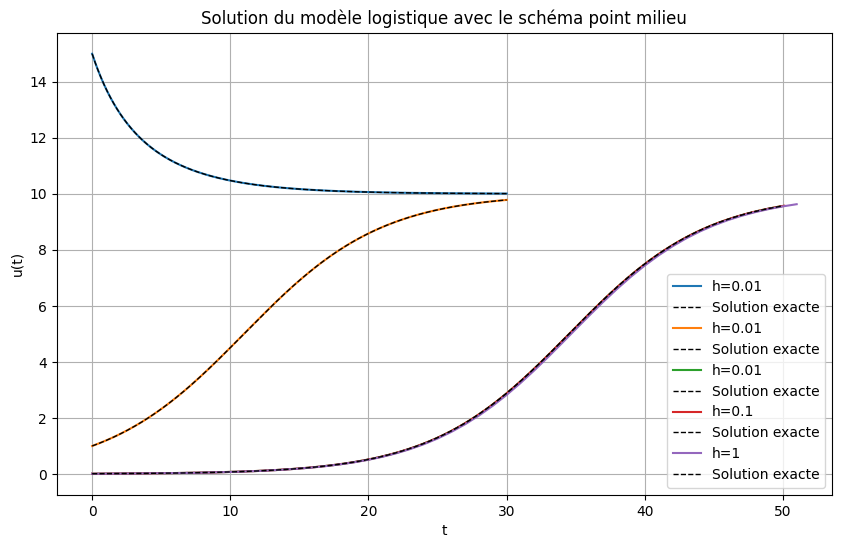

In [33]:
#QUESTION 2.6

def slt_log(r,K,u0,h,t):
    return (u0 * K)/(u0+(K-u0)*np.exp(-r * t))

t_solution = np.linspace(0, 30, 1000)
u_solution = slt_log(0.2, 10, 15,30, t_solution)
plt.figure(figsize=(10, 6))

for a in [(0.2, 10, 15, 0.01,30),(0.2, 10, 1, 0.01,30),(0.2, 10, 0.01, 0.01,50),(0.2, 10, 0.01, 0.1,50),(0.2, 10, 0.01, 1,50)]:
    u, v = fct_point_milieu_log(*a)
    plt.plot(v, u, label=f"h={a[3]}")
    i,j,k,l,m=a
    t_solution = np.linspace(0, m, 1000)

    u_solution = slt_log(i, j, k,m, t_solution)
    plt.plot(t_solution, u_solution, label="Solution exacte", color='black', linestyle="--",linewidth=1)

plt.title("Solution du modèle logistique avec le schéma point milieu")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.legend()
plt.grid()
plt.show()

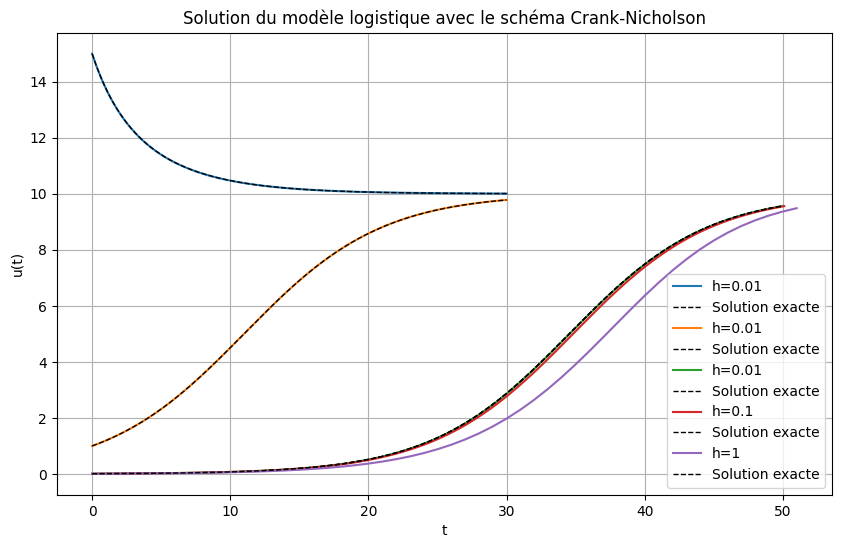

In [34]:
plt.figure(figsize=(10, 6))
for a in [(0.2, 10, 15, 0.01,30),(0.2, 10, 1, 0.01,30),(0.2, 10, 0.01, 0.01,50),(0.2, 10, 0.01, 0.1,50),(0.2, 10, 0.01, 1,50)]:
    u, v = fct_cranck_nicholson_log(*a)
    plt.plot(v, u, label=f"h={a[3]}")
    i,j,k,l,m=a
    t_solution = np.linspace(0, m, 1000)

    u_solution = slt_log(i, j, k,m, t_solution)
    plt.plot(t_solution, u_solution, label="Solution exacte", color='black', linestyle="--",linewidth=1)

plt.title("Solution du modèle logistique avec le schéma Crank-Nicholson")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.legend()
plt.grid()
plt.show()


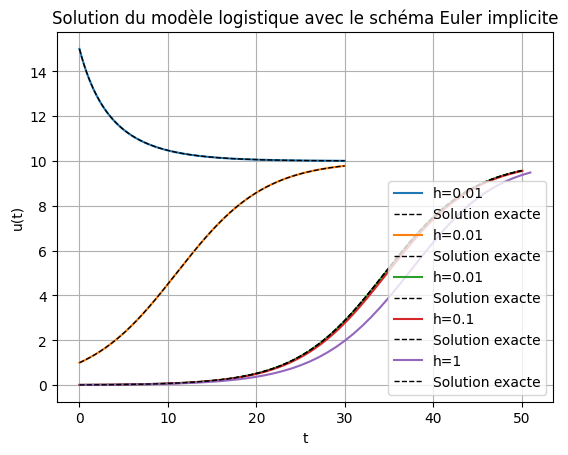

In [35]:
for a in [(0.2, 10, 15, 0.01,30),(0.2, 10, 1, 0.01,30),(0.2, 10, 0.01, 0.01,50),(0.2, 10, 0.01, 0.1,50),(0.2, 10, 0.01, 1,50)]:
    u, v = fct_euler_imp_log(*a)    #cela prend du temps mais ça fonctionne!
    plt.plot(v, u, label=f"h={a[3]}")
    i,j,k,l,m=a
    t_solution = np.linspace(0, m, 1000)

    u_solution = slt_log(i, j, k,m, t_solution)
    plt.plot(t_solution, u_solution, label="Solution exacte", color='black', linestyle="--",linewidth=1)

plt.title("Solution du modèle logistique avec le schéma Euler implicite")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.legend()
plt.grid()
plt.show()

In [36]:
#PARTIE 3

In [ ]:
#QUESTION 3.1

uploaded = files.upload() #Sélectionner le fichier DataTumeur
chemin = list(uploaded.keys())[0]
df = pd.read_csv(chemin, sep='\t', header=None)
t = df[0].values
y = df[1].values
print(df.head())
plt.scatter(df[0], df[1], marker='o')
plt.title("Le volume tumoral en fonction des jours")
plt.xlabel("Jours")
plt.ylabel("Volume")
plt.grid()
plt.show()

In [ ]:
#QUESTION 3.3

def flog(x,u0,r,K):
    return (u0*K)/(u0+(K-u0)*np.exp(-r*x))
def fmalt(x,u0,l):
    return u0*np.exp(l*x)
def fgomp(x,u0,r,K):
    v0=np.log(K/u0)
    return K*np.exp(-v0*np.exp(-r*t))

def erreur(params, t, y):
    u0 = y[0]
    r, K = params
    u_pred = fgomp(t,u0,r,K)
    return np.sum((u_pred - y)**2)


params_init = [0.1, 1000]  # Valeurs initiales pour r et K
result = minimize(erreur, params_init, args=(t, y), bounds=((0, None), (0, None)))

r_estime, K_estime = result.x
print(f"Valeur estimée de r : {r_estime}")
print(f"Valeur estimée de K : {K_estime}")
print(f"Erreur totale (somme des carrés des erreurs) : {result.fun}")

y_pred = fgomp(t, y[0], r_estime, K_estime)

plt.scatter(t, y, label='Données réelles',color='red')
plt.plot(t, y_pred, label=f'Modèle ajusté (r={r_estime:.3f}, K={K_estime:.3f})', linestyle='--')
plt.xlabel('Temps')
plt.ylabel('Volume tumoral')
plt.legend()
plt.grid(True)
plt.title("Ajustement du modèle de Gomperz")
plt.show()

y_pred = fgomp(t, y[0], r_estime, K_estime)

residus = y - y_pred

stat, p_value = stats.shapiro(residus)
print(f"Test de Shapiro-Wilk : Statistique = {stat}, p-value = {p_value}")
if p_value > 0.05:
    print("Les résidus suivent une loi normale.")
else:
    print("Les résidus ne suivent pas une loi normale.")

plt.hist(residus, bins=40, edgecolor='black')
plt.title("Histogramme des résidus")
plt.xlabel("Valeurs des résidus")
plt.ylabel("Fréquence")
plt.show()



In [ ]:
def erreur(params, t, y):
    u0 = y[0]
    l = params[0]
    u_pred = fmalt(t, u0, l)
    return np.sum((u_pred - y) ** 2)

params_init = [0.1]
result = minimize(erreur, params_init, args=(t, y), bounds=[(0, None)])

l_estime = result.x[0]
print(f"Valeur estimée de l : {l_estime:.6f}")
print(f"Erreur totale (somme des carrés des erreurs) : {result.fun:.6f}")

y_pred = fmalt(t, y[0], l_estime)


plt.scatter(t, y, label='Données réelles', color='red')
plt.plot(t, y_pred, label=f'Modèle ajusté (l={l_estime:.6f})', linestyle='--', color='blue')
plt.xlabel('Temps')
plt.ylabel('Volume tumoral')
plt.legend()
plt.grid(True)
plt.title("Ajustement du modèle de Malthus")
plt.show()

y_pred = fmalt(t, y[0], l_estime)

residus = y - y_pred

stat, p_value = stats.shapiro(residus)
print(f"Test de Shapiro-Wilk : Statistique = {stat}, p-value = {p_value}")
if p_value > 0.05:
    print("Les résidus suivent une loi normale.")
else:
    print("Les résidus ne suivent pas une loi normale.")

plt.hist(residus, bins=40, edgecolor='black')
plt.title("Histogramme des résidus")
plt.xlabel("Valeurs des résidus")
plt.ylabel("Fréquence")
plt.show()

In [ ]:
def flog(t, u0, r, K):
        return u0*K / (u0 + ((K - u0) * np.exp(-r * t)))

def erreur(params, t, y):
    u0 = y[0]
    r, K = params
    u_pred = flog(t, u0, r, K)
    return np.sum((u_pred - y) ** 2)

y = df[1].values
t = np.arange(len(y))

params_init = [0.1, 1000]
result = minimize(erreur, params_init, args=(t, y), bounds=((0, None), (0, None)))


r_estime, K_estime = result.x
print(f"Valeur estimée de r : {r_estime}")
print(f"Valeur estimée de K : {K_estime}")
print(f"Erreur totale (somme des carrés des erreurs) : {result.fun:.6f}")

y_pred = flog(t, y[0], r_estime,K_estime)


plt.scatter(t, y, label='Données réelles',color='red')
plt.plot(t, y_pred, label=f'Modèle ajusté (r={r_estime:.3f}, K={K_estime:.3f})', linestyle='--')
plt.xlabel('Temps')
plt.ylabel('Volume tumoral')
plt.legend()
plt.grid(True)
plt.title("Ajustement du modèle Logistique")
plt.show()

y_pred = flog(t, y[0], r_estime, K_estime)

residus = y - y_pred

stat, p_value = stats.shapiro(residus)
print(f"Test de Shapiro-Wilk : Statistique = {stat}, p-value = {p_value}")
if p_value > 0.05:
    print("Les résidus suivent une loi normale.")
else:
    print("Les résidus ne suivent pas une loi normale.")

plt.hist(residus, bins=40, edgecolor='black')
plt.title("Histogramme des résidus")
plt.xlabel("Valeurs des résidus")
plt.ylabel("Fréquence")
plt.show()
